In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import gzip

# Reading the data

In [10]:
with gzip.open('./mapped.bed.gz', 'rt') as f:
    df = pd.read_csv(f, sep="\t", header=None)

# Calculating X, Y and Z

In [17]:
C1 = ((df[2] + df[3]) // 2).astype(int)
C2 = ((df[8] + df[9]) // 2).astype(int)

ValX = (C2 - C1).astype(int)
ValY = (df[9] - df[8]).astype(int)

Cts = defaultdict(int)
for x, y in zip(ValX, ValY):
    Cts[(x, y)] += 1
    
X = np.array([x for x, y in Cts])
Y = np.array([y for x, y in Cts])
Z = np.array([Cts[(x, y)] for x, y in Cts])

# Creating Heatmap

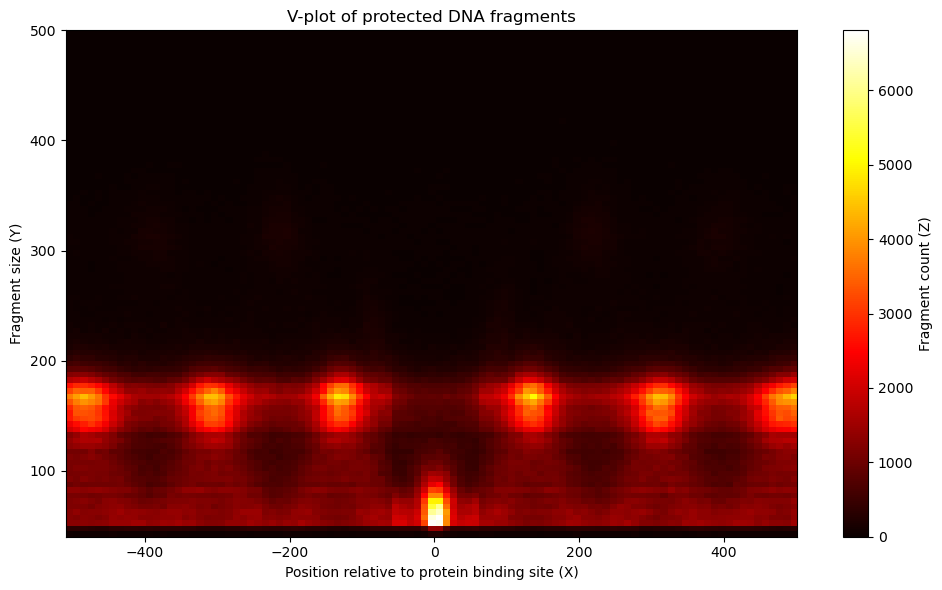

In [35]:
binX = np.arange(X.min(), X.max() + 1, 10)
binY = np.arange(Y.min(), Y.max() + 1, 5)

heatmap, xedges, yedges = np.histogram2d(
    X, Y, bins=[binX, binY], weights=Z
)

plt.figure(figsize=(10, 6))
plt.imshow(
    heatmap.T,
    aspect='auto',
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='hot'
)
plt.colorbar(label='Fragment count (Z)')
plt.xlabel('Position relative to protein binding site (X)')
plt.ylabel('Fragment size (Y)')
plt.title('V-plot of protected DNA fragments')
plt.tight_layout()
plt.show()